# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [ ]:
# Escribe aquí tu código para descargar los datos de tus 3 activos elegidos
!pip -q install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["WFC","ABT","XOM"]
datos = yf.download(
    ticker,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=False
)

datos.head()

[*********************100%***********************]  3 of 3 completed


Price        Adj Close                             Close             \
Ticker             ABT        WFC        XOM         ABT        WFC   
Date                                                                  
2024-01-02  103.769424  46.275784  93.601608  109.849998  49.330002   
2024-01-03  103.457687  45.666031  94.388008  109.519997  48.680000   
2024-01-04  104.836884  46.228886  93.565033  110.980003  49.279999   
2024-01-05  104.666847  46.829258  93.848511  110.800003  49.919998   
2024-01-08  106.178261  46.829258  92.284813  112.400002  49.919998   

Price                         High                                Low  \
Ticker             XOM         ABT        WFC         XOM         ABT   
Date                                                                    
2024-01-02  102.360001  111.000000  49.759998  103.099998  109.559998   
2024-01-03  103.220001  110.250000  49.090000  103.620003  109.290001   
2024-01-04  102.320000  111.029999  49.860001  104.570000  109.510002   
2024-01-05  102.629997  111.050003  50.470001  103.400002  110.029999   
2024-01-08  100.919998  112.519997  49.990002  101.040001  110.919998   

Price                                    Open                          Volume  \
Ticker            WFC         XOM         ABT        WFC         XOM      ABT   
Date                                                                            
2024-01-02  48.820000  100.849998  109.559998  49.049999  100.919998  5058600   
2024-01-03  48.320000  101.660004  110.139999  49.090000  102.269997  4239600   
2024-01-04  48.770000  102.050003  109.680000  48.820000  104.080002  5296100   
2024-01-05  49.290001  102.129997  110.709999  49.400002  103.169998  4127700   
2024-01-08  49.150002   98.900002  111.129997  49.380001  100.730003  5030400   

Price                           
Ticker           WFC       XOM  
Date                            
2024-01-02  14916000  23483000  
2024-01-03  21653600  23490800  
2024-01-04  15917500  19395200  
2024-01-05  15074800  15827400  
2024-01-08  15119700  23370100

In [ ]:
empresa= yf.Ticker("WFC")
empresa.info["sector"]
empresa.info["industry"]

'Banks - Diversified'

In [ ]:
empresa= yf.Ticker("ABT")
empresa.info["sector"]
empresa.info["industry"]

'Medical Devices'

In [ ]:
empresa= yf.Ticker("XOM")
empresa.info["sector"]
empresa.info["industry"]

'Oil & Gas Integrated'

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

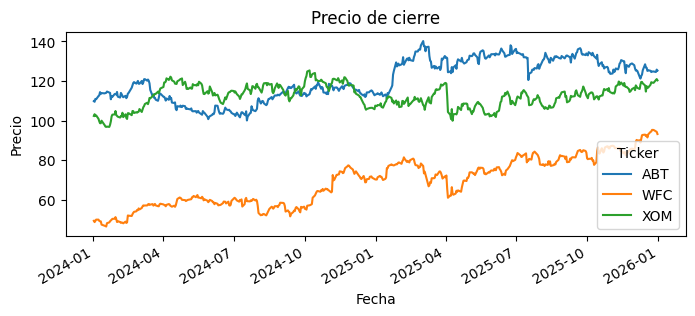

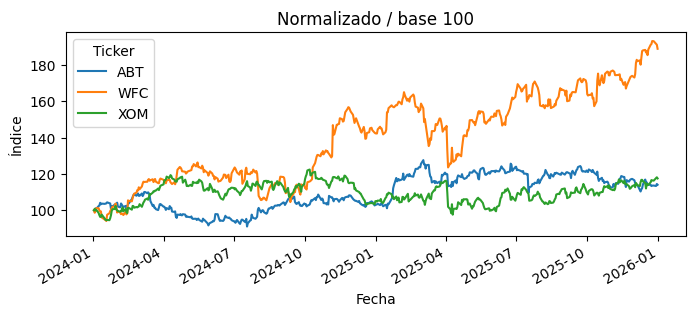

In [134]:
# 1. Extraer los precios de cierre
cierre = datos["Close"]
# 2. Graficar precios originales
cierre.plot(figsize=(8, 3))
plt.title(f"Precio de cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.show()

print("="*90)
# 3. Normalizar y graficar en base 100
precios = datos["Close"]
precios_normalizados = precios / precios.iloc[0] * 100

precios_normalizados.plot(figsize=(8, 3))
plt.title("Normalizado / base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice")
plt.show()

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

Estadísticas de volatilidad (Desviación Estándar):
Ticker
ABT    0.012749
WFC    0.018234
XOM    0.013507
dtype: float64

El activo más volátil es: WFC


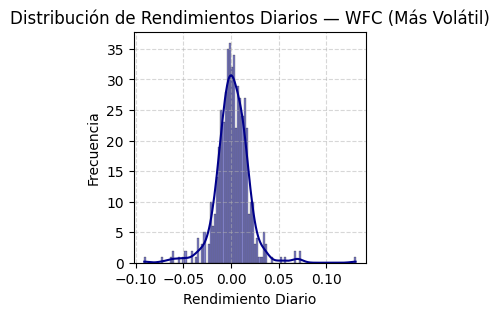

/tmp/ipykernel_5735/614993430.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rendimientos, palette="Set2", color='yellow')


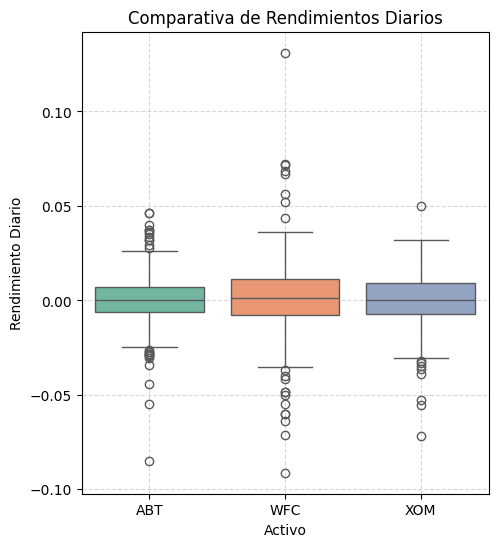

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular rendimientos diarios y eliminar nulos
rendimientos = cierre.pct_change().dropna()
print("Estadísticas de volatilidad (Desviación Estándar):")
volatilidad = rendimientos.std()
print(volatilidad)
print("="*65)
# Identificar el activo más volátil
activo_mas_volatil = volatilidad.idxmax()
print(f"\nEl activo más volátil es: {activo_mas_volatil}")

# 2. Histograma con el activo más volátil
plt.figure(figsize=(3, 3))
sns.histplot(rendimientos[activo_mas_volatil], bins=100, kde=True, color='darkblue')
plt.title(f"Distribución de Rendimientos Diarios — {activo_mas_volatil} (Más Volátil)")
plt.xlabel("Rendimiento Diario")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("="*65)
# 3. Boxplot comparativo de rendimientos
plt.figure(figsize=(5.25, 6))
sns.boxplot(data=rendimientos, palette="Set2",)
plt.title("Comparativa de Rendimientos Diarios")
plt.xlabel("Activo")
plt.ylabel("Rendimiento Diario")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

          WFC       ABT       XOM
WFC  1.000000  0.106094  0.277874
ABT  0.106094  1.000000  0.093626
XOM  0.277874  0.093626  1.000000


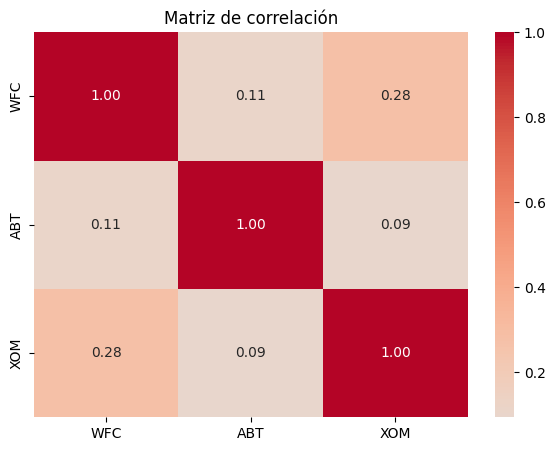

In [ ]:
# 1. Calcular matriz de correlación

datos_rendimientos = pd.DataFrame({
    "WFC": rendimientos["WFC"],
    "ABT": rendimientos["ABT"],
    "XOM": rendimientos["XOM"]
})

correlacion = datos_rendimientos.corr()

correlacion
print(correlacion)

print("="*65)

# 2. Dibujar el Heatmap utilizando Seaborn
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()


## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [ ]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)
datos_rendimientos.describe()


,WFC,ABT,XOM
count,501.000000,501.000000,501.000000
mean,0.001436,0.000344,0.000415
std,0.018234,0.012749,0.013507
min,-0.091199,-0.085244,-0.071956
25%,-0.007491,-0.006134,-0.007091
50%,0.001228,0.000331,0.000446
75%,0.011122,0.007163,0.009257
max,0.131107,0.046188,0.049916


***Recomendación:***


---


Le sugiero no poner todo su dinero en un solo lugar. Combinar la fuerza de WFC para buscar ganancias y con la estabilidad de ABT para protegerse, le dará un portafolio equilibrado, seguro y con buen potencial de crecimiento.